# Experiment 1 (Without my scaler)

## 1. Business Problem

### Objective

The goal of this project is to build a Linear Regression model from scratch using NumPy to predict the median house value of a district based on its demographic and housing characteristics.

### Business Context

A real estate company wants to estimate housing prices across different districts in California. Accurate price estimates can help the company understand the factors associated with housing values and support data-driven real estate decisions.

### Machine Learning Task

This is a supervised learning problem and, more specifically, a regression problem.

* **Input:** Demographic and housing-related features for each district.
* **Target:** Median house value (`MedHouseVal`).
* **Model:** Linear Regression implemented from scratch using NumPy.
* **Optimization:** Batch Gradient Descent.

### Project Goals

The main goals of this experiment are to:

1. Apply our Linear Regression implementation to a real-world dataset.
2. Evaluate the model using appropriate regression metrics.
3. Analyze the model's prediction errors.
4. Understand how feature scale affects Gradient Descent.
5. Compare model performance before and after feature scaling.


## 2. Dataset

### California Housing Dataset

The California Housing dataset contains information about housing characteristics and demographic information for districts in California.

Each row represents a district, while the columns describe different characteristics of that district.

#### Features

| Feature      | Description                              |
| ------------ | ---------------------------------------- |
| `MedInc`     | Median income in the district            |
| `HouseAge`   | Median house age                         |
| `AveRooms`   | Average number of rooms per household    |
| `AveBedrms`  | Average number of bedrooms per household |
| `Population` | District population                      |
| `AveOccup`   | Average number of household members      |
| `Latitude`   | Geographic latitude                      |
| `Longitude`  | Geographic longitude                     |

#### Target Variable

The target variable is:

`MedHouseVal`

It represents the median house value for the district.

#### Why This Dataset?

This dataset is suitable for our experiment because it provides a real-world regression problem with multiple numerical features.

It also provides an opportunity to investigate an important practical issue in Machine Learning: the effect of feature scaling on Gradient Descent.


## 3. Data Loading & Initial Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing 

In [2]:
housing = fetch_california_housing(as_frame = True)
df = housing.frame

In [3]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.shape

(20640, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


##### Initial Observation
The dataset contains no missing values, so no missing values processing is required at this stage. The dataset contains 20640 rows and 9 columns. The features have noticeably different scales. For example, 'Population' has values much larger than features such as 'AveRooms' and 'HouseAge'. This may affect the convergence of Gradient Descent.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Analysis

Before analyzing the individual features, we first examine the distribution of the target variable, 'MedHouseVal'.
Understanding the target distribution helps us identify its central tendency, spread, skewness, and potential outliers.

In [7]:
target = df['MedHouseVal']
print(f'Mean: {target.mean()}')
print(f'Median: {target.median()}')
print(f'Standard Deviation: {target.std()}')
print(f'Min Value: {target.min()}')
print(f'Max Value: {target.max()}')

Mean: 2.0685581690891475
Median: 1.797
Standard Deviation: 1.1539561587441385
Min Value: 0.14999
Max Value: 5.00001


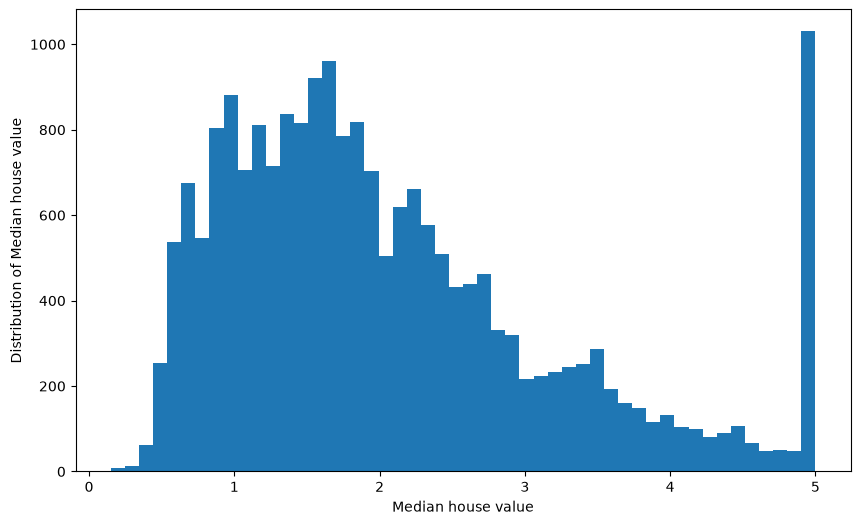

In [8]:
plt.figure(figsize = (10, 6))
plt.hist(target, bins = 50)
plt.xlabel('Median house value')
plt.ylabel('Distribution of Median house value')
plt.show()

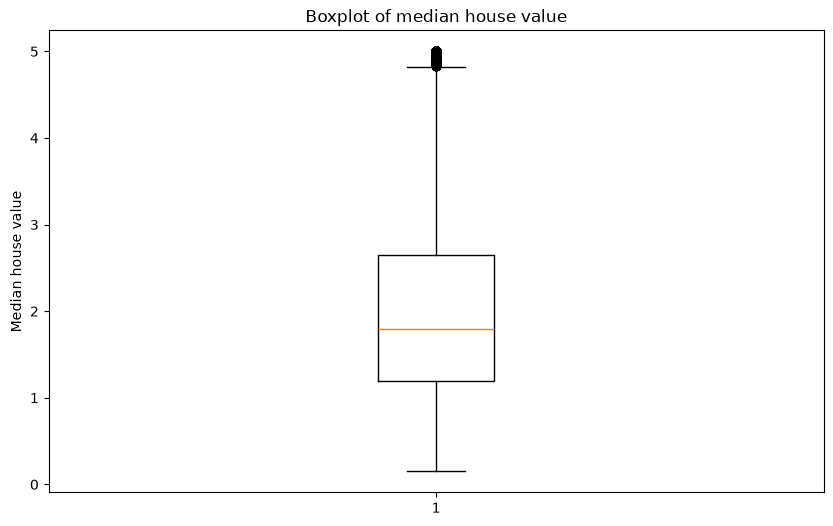

In [9]:
plt.figure(figsize = (10, 6))
plt.boxplot(target)
plt.ylabel('Median house value')
plt.title('Boxplot of median house value')
plt.show()

### 4.2 Feature Distributions

We now examine the distributions of the input features to understand their ranges, spread, skewness, and potential anomalies.

In [10]:
features = df.drop(columns = 'MedHouseVal')

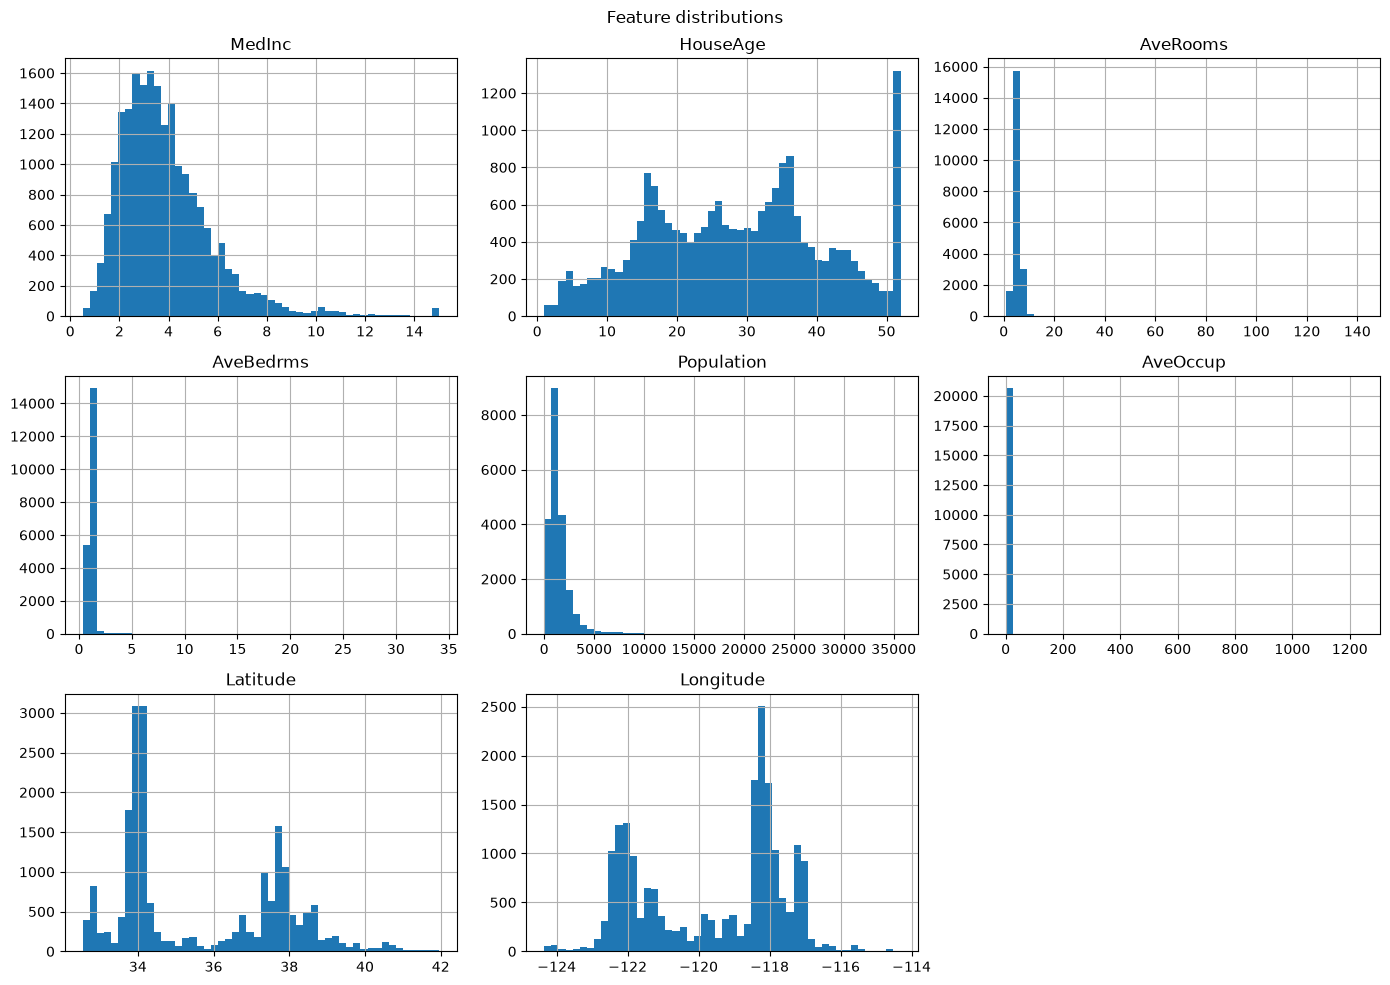

In [11]:
features.hist(figsize = (14, 10), bins = 50)
plt.suptitle('Feature distributions')
plt.tight_layout()
plt.show()

### 4.3 Correlation Anaysis

Correlation analysis is used to examine the linear relationship between the numerical features and the target variable.
This can help us identify features that may contain useful predictive information for the regression model.

In [12]:
corr_matrix = df.corr(numeric_only = True)
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [13]:
target_corr = corr_matrix['MedHouseVal'].sort_values(ascending = False)
target_corr

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

### 4.4 Visualize Correlations

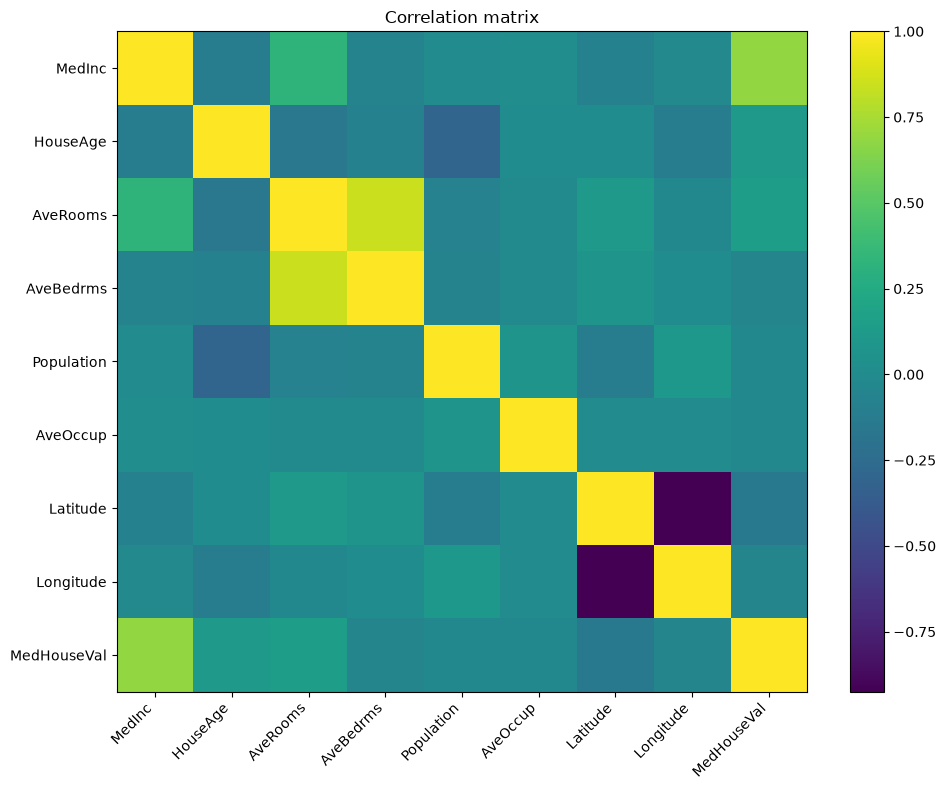

In [14]:
plt.figure(figsize = (10, 8))

plt.imshow(corr_matrix, aspect = 'auto')

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation = 45,
    ha = 'right'
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

In [15]:
top_feature = target_corr.index[1]

print('Top correlated feature:', top_feature)

Top correlated feature: MedInc


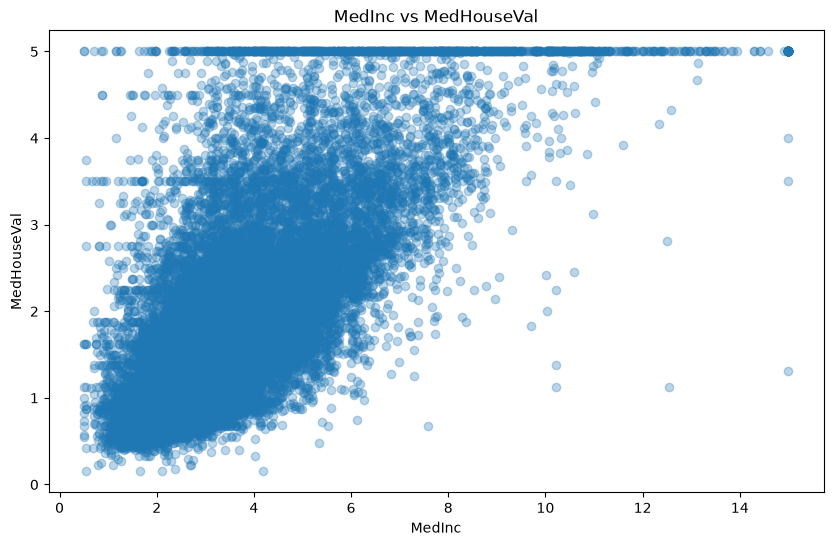

In [16]:
plt.figure(figsize = (10, 6))

plt.scatter(
    df[top_feature],
    df['MedHouseVal'],
    alpha = 0.3
)

plt.xlabel(top_feature)
plt.ylabel('MedHouseVal')
plt.title(f"{top_feature} vs MedHouseVal")
plt.show()

### 4.5 Feature vs Target Relationship

In [17]:
top_features = (
    target_corr
    .drop('MedHouseVal')
    .abs()
    .sort_values(ascending = False)
    .head(4)
    .index
)

top_features

Index(['MedInc', 'AveRooms', 'Latitude', 'HouseAge'], dtype='str')

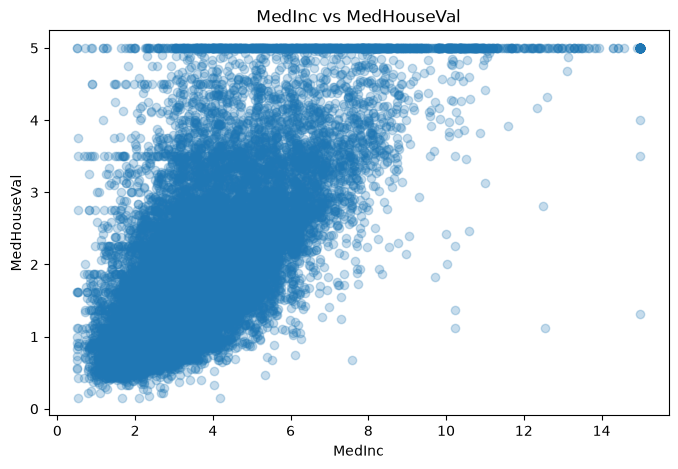

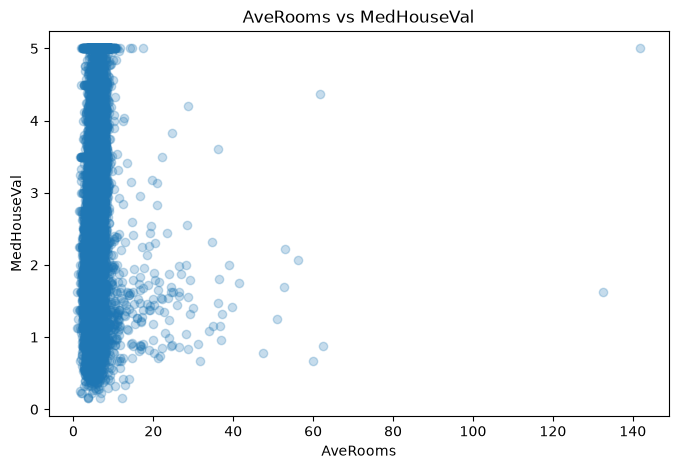

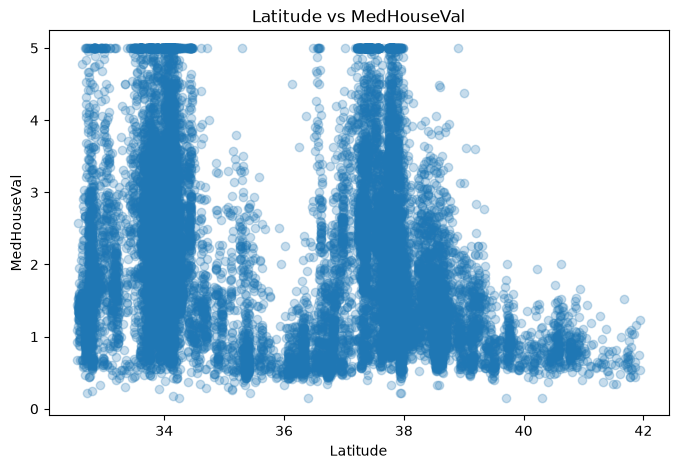

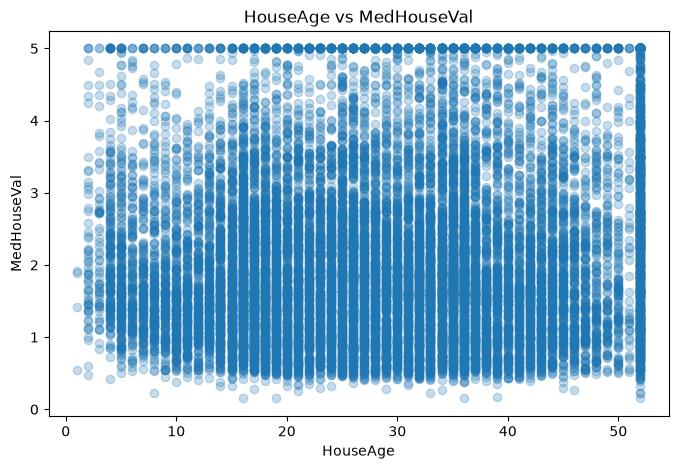

In [18]:
for feature in top_features:

    plt.figure(figsize = (8, 5))

    plt.scatter(
        df[feature],
        df['MedHouseVal'],
        alpha = 0.25
    )

    plt.xlabel(feature)
    plt.ylabel('MedHouseVal')
    plt.title(f'{feature} vs MedHouseVal')

    plt.show()

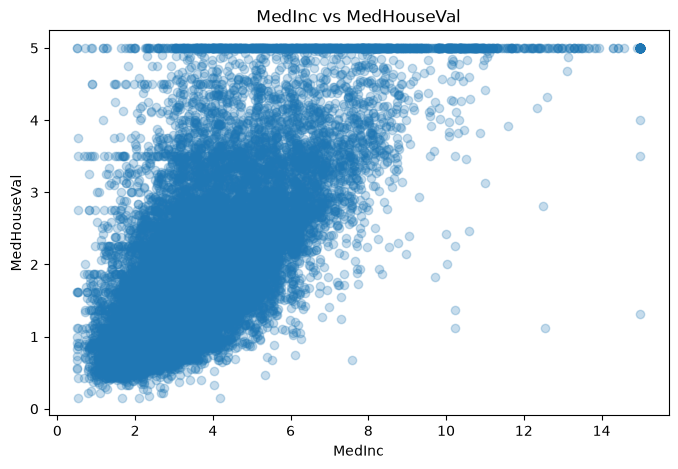

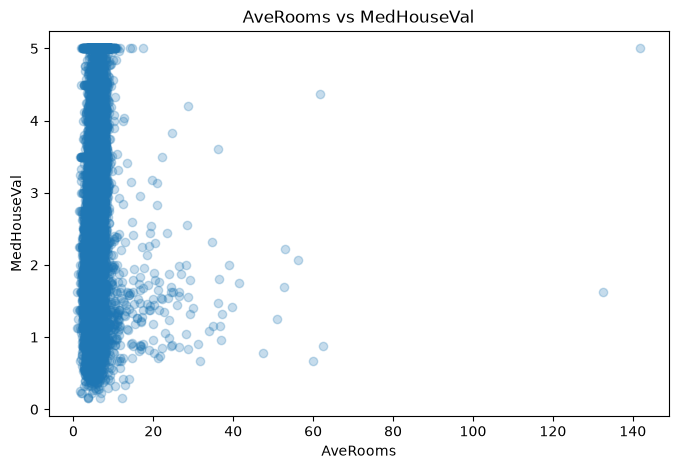

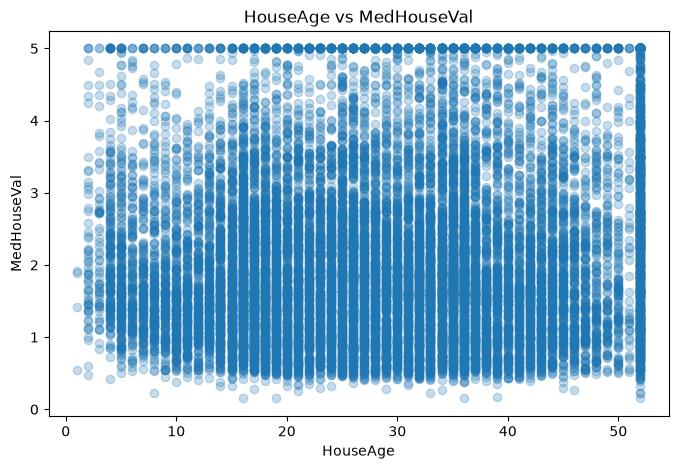

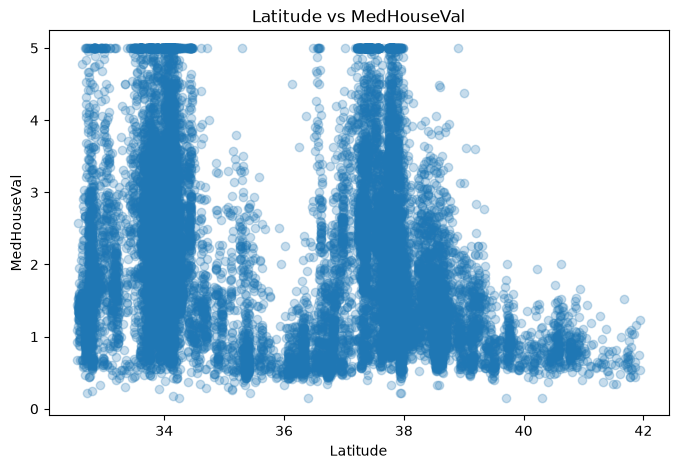

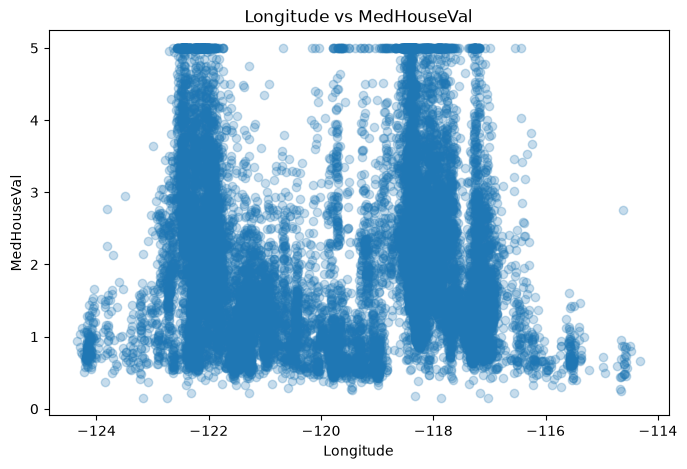

In [19]:
top_features = [
    'MedInc',
    'AveRooms',
    'HouseAge',
    'Latitude',
    'Longitude'
]

for feature in top_features:
    plt.figure(figsize=(8, 5))

    plt.scatter(
        df[feature],
        df['MedHouseVal'],
        alpha = 0.25
    )

    plt.xlabel(feature)
    plt.ylabel('MedHouseVal')
    plt.title(f'{feature} vs MedHouseVal')

    plt.show()

#### Findings

The scatter plots show that 'MedInc' has the clearest positive relationship with 'MedHouseVal'. This observation is consistent with its relatively strong Pearson correlation of 0.688.
'AveRooms' shows a weak positive relationship with the target, but the observations are widely dispersed and no strong clear linear pattern is visible.
The remaining features show relatively weak individual linear relationships with 'MedHouseVal'. In particular, 'AveOccup' and 'Population' have correlations close to zero.
The geographical features, 'Latitude' and 'Longitude', show weak linear correlations, but their scatter plots suggest the presence of clusters rather than a simple linear relationship.
These observations suggest that 'MedInc may be an important predictor, while the predictive contribution of the remaining features should be evaluated using a multivariate model rather than correlation alone.

### 4.6 Outlier Analysis

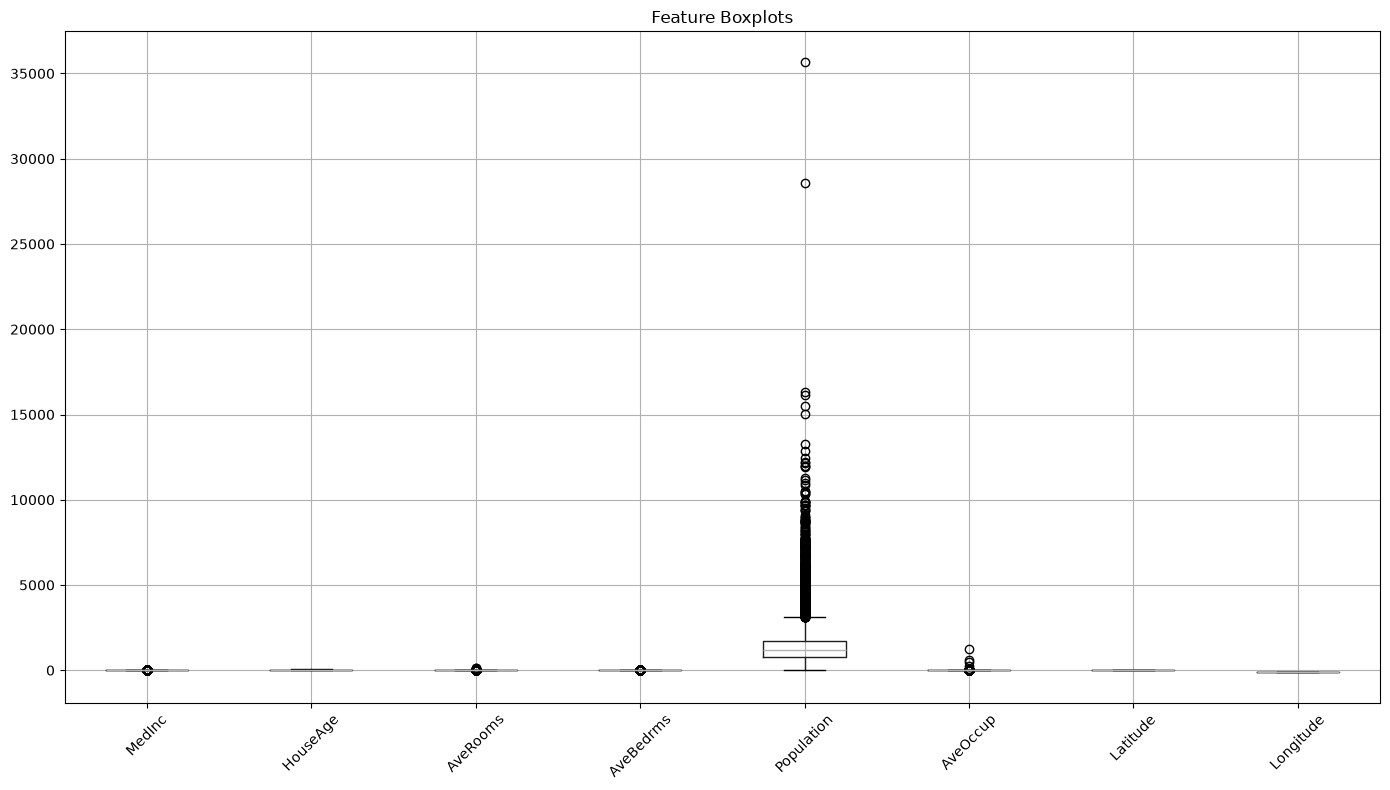

In [20]:
plt.figure(figsize = (14, 8))

df[features.columns].boxplot()

plt.xticks(rotation = 45)
plt.title('Feature Boxplots')

plt.tight_layout()
plt.show()

#### 4.6.1 Why Analyze Outliers?

Extreme values were observed in several features during the distribution analysis. 
Before deciding how to handle them, we first identify potential statistical outliers.
We will use the Interquartile Range (IQR) method to identify observations that fall outside the expected range of each feature.
It is important to note that identifying an outlier does not necessarily mean that the observation is invalid or should be removed.

#### 4.6.2 IQR Method
Q1 = 25th percentile
Q3 = 75th percentile

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

In [21]:
def detect_outliers_iqr(df, columns):
    results = []

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[column] < lower_bound) |
            (df[column] > upper_bound)
        ]

        results.append({
            'Feature': column,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Outlier Count': len(outliers),
            'Outlier Percentage': len(outliers) / len(df) * 100
        })

    return pd.DataFrame(results)

In [22]:
outlier_summary = detect_outliers_iqr(df, df.columns)
outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,MedInc,2.563400,4.743250,2.179850,-0.706375,8.013025,681,3.299419
1,HouseAge,18.000000,37.000000,19.000000,-10.500000,65.500000,0,0.000000
2,AveRooms,4.440716,6.052381,1.611665,2.023219,8.469878,511,2.475775
3,AveBedrms,1.006079,1.099526,0.093447,0.865909,1.239697,1424,6.899225
4,Population,787.000000,1725.000000,938.000000,-620.000000,3132.000000,1196,5.794574
5,AveOccup,2.429741,3.282261,0.852520,1.150961,4.561041,711,3.444767
6,Latitude,33.930000,37.710000,3.780000,28.260000,43.380000,0,0.000000
7,Longitude,-121.800000,-118.010000,3.790000,-127.485000,-112.325000,0,0.000000
8,MedHouseVal,1.196000,2.647250,1.451250,-0.980875,4.824125,1071,5.188953


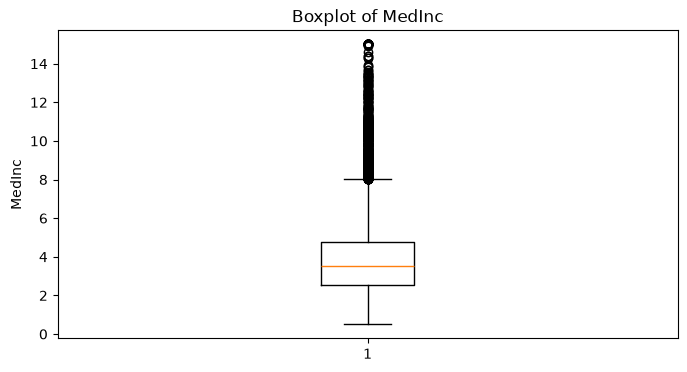

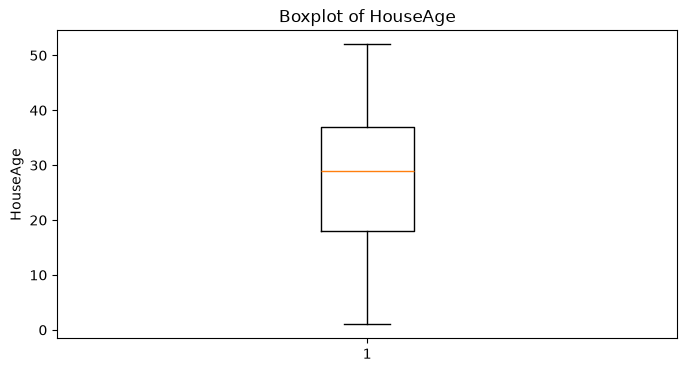

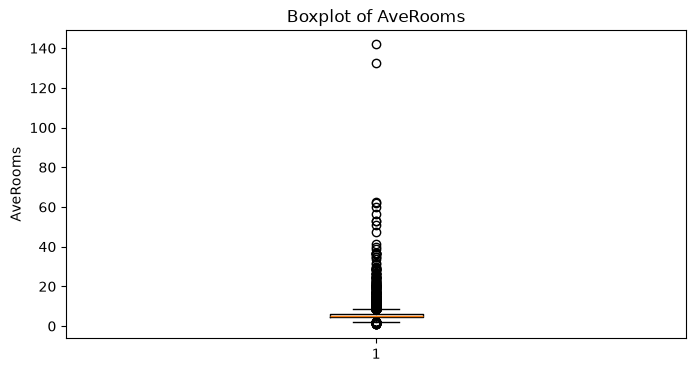

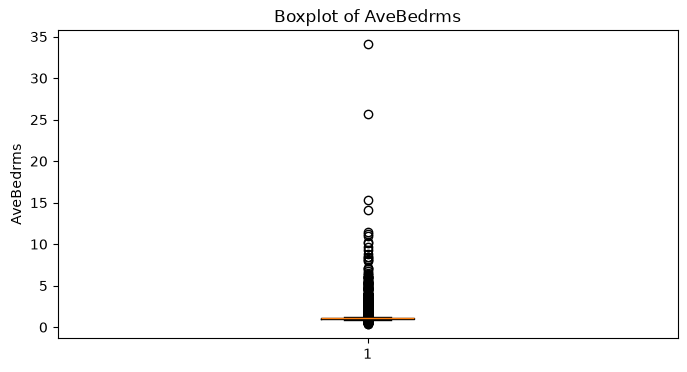

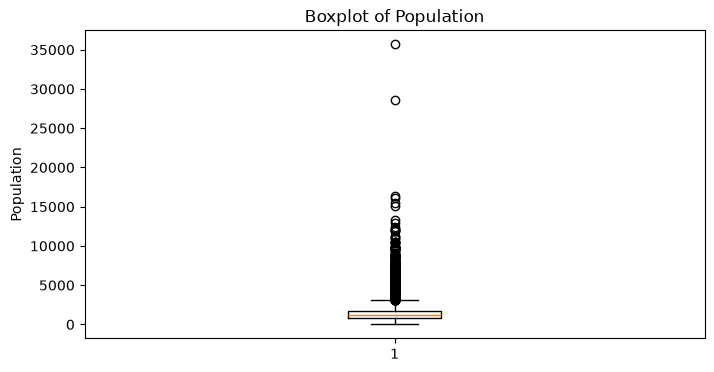

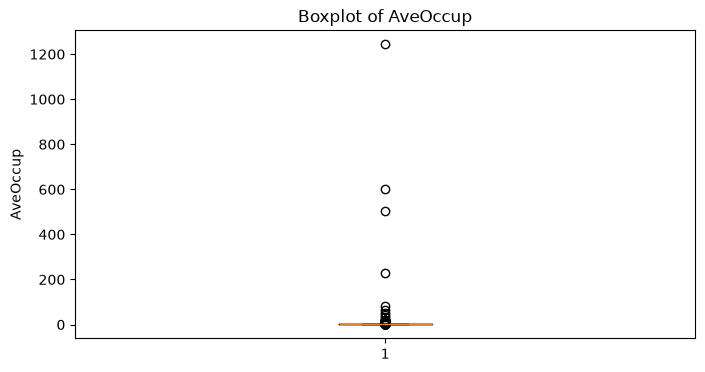

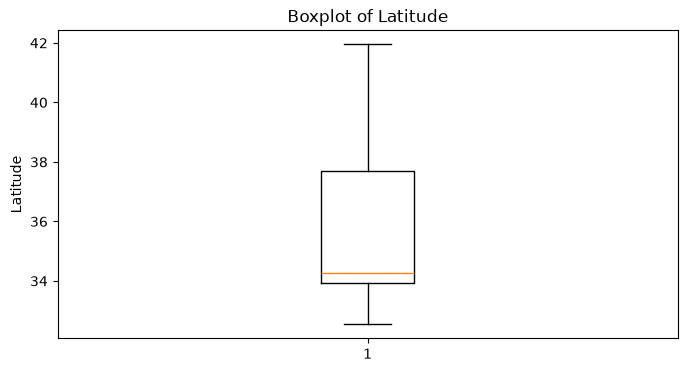

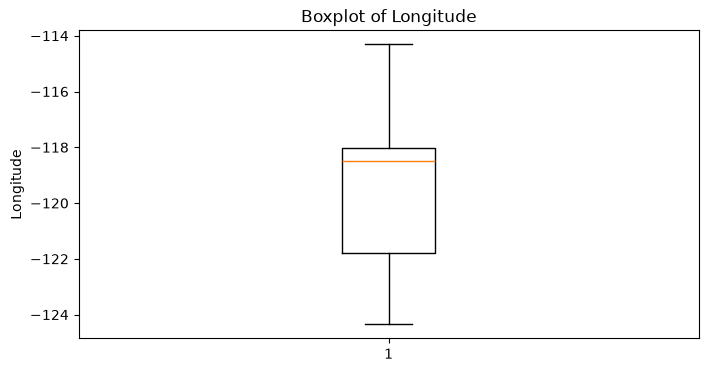

In [23]:
for feature in features.columns:

    plt.figure(figsize = (8, 4))

    plt.boxplot(df[feature])

    plt.ylabel(feature)
    plt.title(f'Boxplot of {feature}')

    plt.show()

#### Findings

The IQR analysis identified potential outliers in several numerical features.

`MedInc`, `AveRooms`, `AveBedrms`, `Population`, and `AveOccup` contain varying proportions of observations outside the IQR-based bounds. `AveBedrms` has the highest proportion of potential outliers among the input features at approximately 6.9%, followed by `Population` at approximately 5.8%.

No IQR-based outliers were detected in `HouseAge`, `Latitude`, or `Longitude`.

The target variable, `MedHouseVal`, also contains potential outliers according to the IQR method. However, these observations will not be removed at this stage. An observation being statistically unusual does not necessarily mean that it is invalid, and the target distribution shows an accumulation near its upper range.

Therefore, we will retain the observations and evaluate their effect on the Linear Regression model during the modeling stage.

## 5. Baseline Linear Regression

Before applying feature scaling or other preprocessing techniques, we first train our Linear Regression implementation on the original feature values.

This model serves as a baseline that will allow us to measure the effect of subsequent preprocessing and modeling improvements.

### 5.1 Prepare Features & Target

In [24]:
X = df.drop(columns = 'MedHouseVal').values
y = df['MedHouseVal'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (20640, 8)
y shape: (20640,)


### 5.2 Train / Test Split

In [25]:
np.random.seed(42)

indices = np.random.permutation(len(X))

test_size = int(0.2 * len(X))

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


### 5.3 Train my model

In [26]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / 'src'

sys.path.insert(0, str(src_path))

In [27]:
from ml_from_scratch.linear_models.linear_regression import LinearRegression

In [28]:
model = LinearRegression(
    learning_rate = 0.01,
    n_iterations = 1000,
    tolerance = 1e-7,
    verbose = True
)

model.fit(X_train, y_train)

Iteration    1, Cost: 2.81
Iteration  101, Cost: nan
Iteration  201, Cost: nan
Iteration  301, Cost: nan
Iteration  401, Cost: nan
Iteration  501, Cost: nan
Iteration  601, Cost: nan
Iteration  701, Cost: nan
Iteration  801, Cost: nan
Iteration  901, Cost: nan
Iteration 1000, Cost: nan


d:\My Courses\Coursera\ML Specialization\ML from scratch\src\ml_from_scratch\linear_models\linear_regression.py:24: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m) * np.sum((pred - y) ** 2))
c:\Users\B2B\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
d:\My Courses\Coursera\ML Specialization\ML from scratch\src\ml_from_scratch\linear_models\linear_regression.py:70: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(previous_cost - cost) < self.tolerance:
d:\My Courses\Coursera\ML Specialization\ML from scratch\src\ml_from_scratch\linear_models\linear_regression.py:32: RuntimeWarning: overflow encountered in matmul
  dw = (1 / m) * (X.T @ error)
d:\My Courses\Coursera\ML Specialization\ML from scratch\src\ml_from_scratch\linear_models\linear_regression.py:57: RuntimeWarning: invalid value encountered in

### 5.4 Predictions

In [29]:
pred = model.predict(X_test)

In [30]:
print("Weights:")
print(model.w)

print("\nBias:")
print(model.b)

print("\nLast 10 costs:")
print(model.cost_history[-10:])

print("\nAny NaN in weights:", np.isnan(model.w).any())
print("Any Inf in weights:", np.isinf(model.w).any())

print("\nAny NaN in predictions:", np.isnan(pred).any())
print("Any Inf in predictions:", np.isinf(pred).any())

Weights:
[nan nan nan nan nan nan nan nan]

Bias:
nan

Last 10 costs:
[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]

Any NaN in weights: True
Any Inf in weights: False

Any NaN in predictions: True
Any Inf in predictions: False


In [31]:
print("First cost:", model.cost_history[0])
print("Last cost:", model.cost_history[-1])
print("Minimum cost:", np.min(model.cost_history))
print("Maximum cost:", np.max(model.cost_history))

First cost: 2.8148711615515656
Last cost: nan
Minimum cost: nan
Maximum cost: nan


### 5.5 Evaluation

In [32]:
mse = np.mean((y_test - pred) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test - pred))

ss_res = np.sum((y_test - pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)

In [33]:
print(f'MSE  : {mse:.6f}')
print(f'RMSE : {rmse:.6f}')
print(f'MAE  : {mae:.6f}')
print(f'R2   : {r2:.6f}')

MSE  : nan
RMSE : nan
MAE  : nan
R2   : nan


### 5.6 Baseline Results

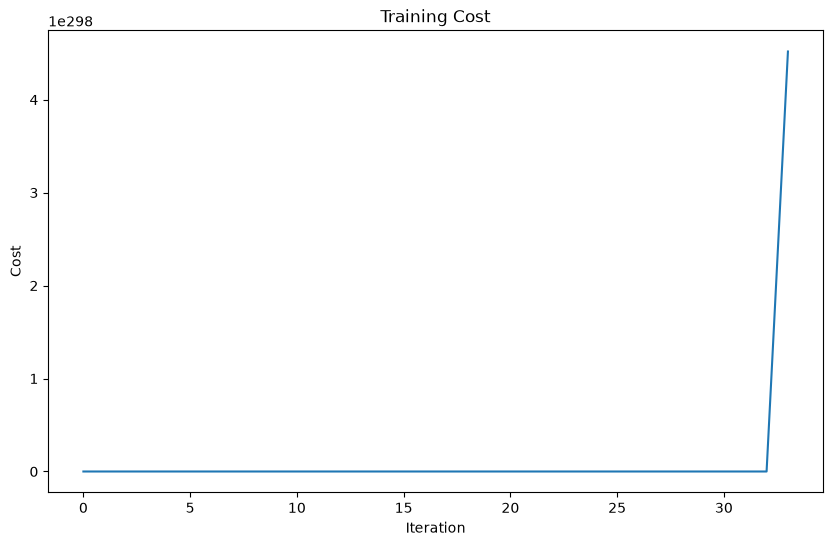

In [34]:
plt.figure(figsize = (10, 6))
plt.plot(model.cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost')
plt.show()

The baseline Linear Regression model was trained using the original,
unscaled feature values.

The model initially produced a finite training cost, but the optimization
became numerically unstable during gradient descent. The model parameters
eventually became NaN, resulting in NaN predictions and evaluation metrics.

This behavior indicates that the different scales of the input features
make gradient descent unstable when using the current learning rate.

Therefore, feature scaling will be investigated in the next section to
improve optimization stability and convergence.

# Experiment 2 (After implementing my scaler)

In [35]:
from ml_from_scratch.preprocessing.scaler import MyStandardScaler

scaler = MyStandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
print('Scaled mean:')
print(np.mean(X_train_scaled, axis = 0))

print('\nScaled std:')
print(np.std(X_train_scaled, axis = 0))

Scaled mean:
[-6.59266865e-15 -6.68608149e-17  8.01559239e-15 -1.17273358e-15
 -2.60880895e-18 -1.13675656e-16  7.99652724e-14 -3.87910056e-13]

Scaled std:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [37]:
print('Original X_train:')
print(X_train[:3])

print('\nScaled X_train:')
print(X_train_scaled[:3])

Original X_train:
[[ 3.25960000e+00  3.30000000e+01  5.01765650e+00  1.00642055e+00
   2.30000000e+03  3.69181380e+00  3.27100000e+01 -1.17030000e+02]
 [ 3.81250000e+00  4.90000000e+01  4.47354497e+00  1.04100529e+00
   1.31400000e+03  1.73809524e+00  3.37700000e+01 -1.18160000e+02]
 [ 4.15630000e+00  4.00000000e+00  5.64583333e+00  9.85119048e-01
   9.15000000e+02  2.72321429e+00  3.46600000e+01 -1.20480000e+02]]

Scaled X_train:
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]]


In [38]:
print('Training mean:')
print(scaler.mean)

print('\nTest mean:')
print(np.mean(X_test, axis = 0))

Training mean:
[ 3.88075426e+00  2.86082849e+01  5.43523502e+00  1.09668475e+00
  1.42645300e+03  3.09696119e+00  3.56431492e+01 -1.19582290e+02]

Test mean:
[ 3.83033798e+00  2.87642926e+01  5.40405863e+00  1.09663675e+00
  1.42157171e+03  2.96543102e+00  3.55867103e+01 -1.19519360e+02]


## 6. Linear Regression with Scaled Data

### 6.1 Train My model on scaled data

In [39]:
scaled_model = LinearRegression(learning_rate = 0.01, n_iterations = 1000,
                    tolerance = 1e-7, verbose = True)

scaled_model.fit(X_train_scaled, y_train)

Iteration    1, Cost: 2.81
Iteration  101, Cost: 0.65
Iteration  201, Cost: 0.36
Iteration  301, Cost: 0.31
Iteration  401, Cost: 0.30
Iteration  501, Cost: 0.29
Iteration  601, Cost: 0.29
Iteration  701, Cost: 0.28
Iteration  801, Cost: 0.28
Iteration  901, Cost: 0.28
Iteration 1000, Cost: 0.27


In [40]:
pred_scaled = scaled_model.predict(X_test_scaled)

### 6.2 Evalute my model using my metrices implementation

In [41]:
from ml_from_scratch.metrics.regression import (
    mean_squared_error,
    root_mean_squared_error,
    mean_abs_error,
    r2_score,
    test_all_metrices
)

In [ ]:
mse_scaled = mean_squared_error(y_test, pred_scaled)
rmse_scaled = root_mean_squared_error(y_test, pred_scaled)
mae_scaled = mean_abs_error(y_test, pred_scaled)
r2_scaled = r2_score(y_test, pred_scaled)

print(f'MSE  : {mse_scaled:.6f}')
print(f'RMSE : {rmse_scaled:.6f}')
print(f'MAE  : {mae_scaled:.6f}')
print(f'R2   : {r2_scaled:.6f}')

MSE  : 0.567185
RMSE : 0.753117
MAE  : 0.547676
R2   : 0.567169


In [43]:
test_all_metrices(y_test, pred_scaled)

MSE  : 0.567185
RMSE : 0.753117
MAE  : 0.547676
R2   : 0.567169


### 6.3 Cost Visualization

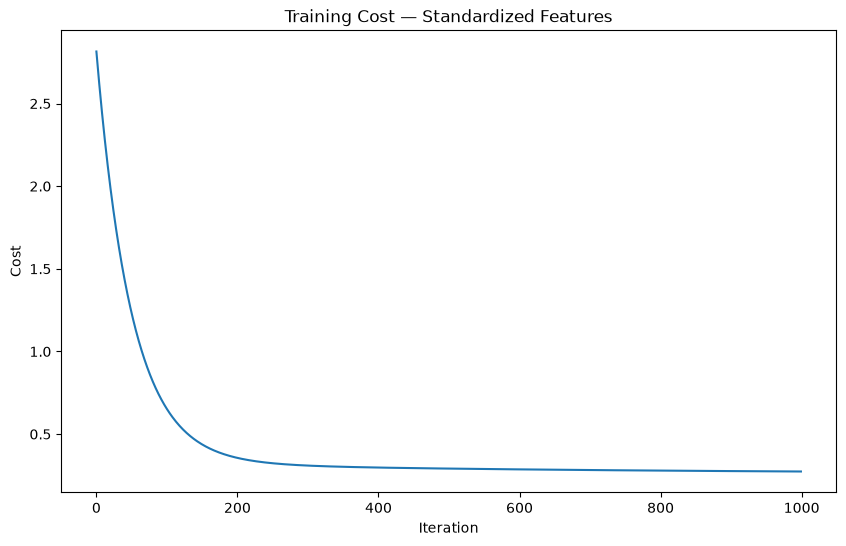

In [45]:
plt.figure(figsize = (10, 6))

plt.plot(scaled_model.cost_history)

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost — Standardized Features')

plt.show()

In [46]:
print('Final training cost:', scaled_model.cost_history[-1])
print('Number of iterations:', scaled_model.n_iter_)

print('Any NaN in weights:', np.isnan(scaled_model.w).any())
print('Any Inf in weights:', np.isinf(scaled_model.w).any())

print('Any NaN in predictions:', np.isnan(pred_scaled).any())
print('Any Inf in predictions:', np.isinf(pred_scaled).any())

Final training cost: 0.27386194648571244
Number of iterations: 1000
Any NaN in weights: False
Any Inf in weights: False
Any NaN in predictions: False
Any Inf in predictions: False


### 6.4 Scaling Results

After standardizing the input features using the custom
'MyStandardScaler', the Linear Regression model became numerically stable.

Unlike the baseline model trained on the original feature values, which
eventually produced NaN values, the scaled model successfully converged
throughout the 1,000 gradient descent iterations.

The final evaluation results on the test set were:

- MSE: 0.567185
- RMSE: 0.753117
- MAE: 0.547676
- R2: 0.567169

The training cost decreased consistently from approximately 2.81 to 0.27,
showing that gradient descent was able to optimize the model successfully.

This experiment demonstrates the importance of feature scaling when using
gradient-based optimization, especially when input features have very
different numerical ranges.